In [2]:
### run this tab twice to remove warnings
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import peslearn

### Load ML model from file and print ML energies

#### Use following if you encounter a error regarding precision:
##### ERROR: "RuntimeError: expected scalar type Double but found Float"
    This bug is only encountered in NN model (in my Mac/Linux Machines) 
    However to solve it: 
    (a) open compute_energy.py (file) --> goto pes (function) --> 
    (b) replace "E = model(x)" with "E = model(x.double())"
    or add line x = x.double() after     x = torch.Tensor(data=newX)



In [3]:
# select appropriate path and model name (path uses UNIX separator)
input_dir = os.getcwd()+'/'
out_peslearn = input_dir + 'peslearn_out/'
test_path2 = out_peslearn + 'model1_data/'
os.chdir(test_path2)

In [4]:
from compute_energy import pes

### plot trial curve

In [31]:
# creating r_n points at 5 degree
r_n = 51 # number of points with 0.1 Ang. interval
R_ini = 3.0 # initial R value (adjust for plot)
E_inf = -76.97764842
b =np.zeros(4) # array with dimentions of input coordinates
e1 = np.zeros(r_n)
r =  np.zeros(r_n)

# angular coordinates at which curve needs to be tested
phi_pes = 0.0
theta2_pes = 0.0
theta1_pes = 40.0

for i in range (r_n):
    r_pes = ((i/10.0)+R_ini)   # input R 3. to 8.
    b =np.array([r_pes,phi_pes,theta2_pes,theta1_pes])
    E = pes(b, cartesian=False)  # cartition is false for r/theta r
    e1[i] = E[0,0]
    r[i] = r_pes
e1

array([-76.97605685, -76.97661403, -76.97701655, -76.97731353,
       -76.97752333, -76.97766474, -76.97775514, -76.97780853,
       -76.97783568, -76.97784481, -76.97784207, -76.97783203,
       -76.97781792, -76.97780196, -76.97778559, -76.97776971,
       -76.97775485, -76.97774125, -76.97772901, -76.97771813,
       -76.97770855, -76.97770016, -76.97769287, -76.97768655,
       -76.97768111, -76.97767642, -76.9776724 , -76.97766895,
       -76.977666  , -76.97766348, -76.97766133, -76.97765948,
       -76.97765791, -76.97765657, -76.97765541, -76.97765443,
       -76.97765358, -76.97765285, -76.97765222, -76.97765167,
       -76.97765119, -76.97765077, -76.9776504 , -76.97765007,
       -76.97764977, -76.9776495 , -76.97764926, -76.97764903,
       -76.97764882, -76.97764862, -76.97764843])

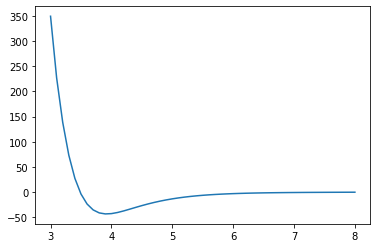

In [32]:
# plotting the bayesian/nn learned curve for testing
e2 = (e1-E_inf)*219474.63   # converting to cm-1
x = np.arange(len(e2))/10.0+R_ini
fig, ax = plt.subplots()
plt.plot(x,e2)


In [33]:
print("Energy minimum at tested curve")
min(e2)

Energy minimum at tested curve


-43.1016326396712

### Use below section once to create array file (containing coordinates) 

In [34]:
# template for creating 4D collision coordinates (step size halved)

A = np.ndarray(shape=(1,4)) # junk array initialization
r1 = np.arange(3.1,8.1,0.1) 
r_n = len(r1) # saving number of R data points
r4 = np.atleast_2d(r1).T   # creating r column vector
for i_phi in tqdm(range (0,91,15)):
    for j_theta2 in range (0,91,15):
        for k_theta1 in range (0,181,15):
            b = np.array([i_phi,j_theta2,k_theta1])
            c = np.tile(b,(r_n,1))  # creating angles as columns
            d = np.c_[ r4, c ]        # joining r and columns
            A = np.vstack([A, d]) # repeating for different geoms and joining
A = np.delete(A, 0, 0) # deleting first row (empty)

# save coordinates
np.savetxt("geom_dense.csv", A, delimiter=",",fmt='%.4f')

100%|██████████| 7/7 [00:00<00:00, 43.98it/s]


In [35]:
# load coordinates directly from previously saved files
B_var2 = np.loadtxt("geom_dense.csv", delimiter=",")
len(B_var2)

31850

In [36]:
result = B_var2
predicted_energies = pes(result, cartesian=False)
final_data = np.c_[ result, predicted_energies ]
np.savetxt("E_PESLearn.dat", final_data, delimiter=",",fmt='%.2f,%d,%d,%d,%.16f')